In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║              USER CONFIG — edit this cell only           ║
# ╚══════════════════════════════════════════════════════════╝

# Path to a reference image containing a clearly visible person (jpg/png)
# This is your final test image that we will use in the last cell
IMAGE_PATH = '/path/to/person.jpg'

# Directory containing .mp4 training videos (searched recursively)
# This is where we save all the videos inputs that we want to use as a training dataset
# make sure to take the video corresponding to the IMAGE_PATH out to prevent data leakage
VIDEO_DIR = '/path/to/data_processed'

# Where to save/load the cached training samples (.pkl)
# Set USE_CACHED_SAMPLES = True on subsequent runs to skip re-extraction
SAMPLES_PATH     = '/path/to/training_samples.pkl'

# Once you finished the sampling, you can turn this on to repetitive sampling
USE_CACHED_SAMPLES = False   # set True after first run to reuse saved samples


In [2]:
# Cell 1 — Installs
!pip install ultralytics kornia --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 91.3 MB/s eta 0:00:00


In [3]:
# Cell 2 — Imports
import cv2
import random
import numpy as np
import torch
import torch.nn.functional as F
import kornia
import kornia.augmentation as K
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Cell 3 — Training hyperparams (no need to edit for a standard run)
# ── Patch geometry ────────────────────────────────────────
PATCH_H          = 200
PATCH_W          = 150
PATCH_SCALE      = 0.6
SHIRT_TOP        = 0.20
SHIRT_BOT        = 0.48

# ── Optimisation ──────────────────────────────────────────
EPSILON          = 1.0
LR               = 0.005
NUM_STEPS        = 1600
EOT_N            = 6
TOP_K            = 20      # coarse anchor top-K
FINE_TOP_K       = 40      # fine anchor top-K (stride-8 grid is 3x denser)

# ── Loss weights ──────────────────────────────────────────
# V12 over V10:
#   - box_disruption_loss removed (only +3.8% in V10, wasting 40% of budget)
#   - suppress loss now attacks fine anchors (stride-8) V10 ignored entirely
#   - max-anchored suppress: targets the single anchor driving NMS, not BCE mean
#   - SUPPRESS_LOSS_W 0.4->0.75, MASK_LOSS_W 0.2->0.25 (box budget redirected)
SUPPRESS_LOSS_W  = 0.75
MASK_LOSS_W      = 0.25
FINE_SUPPRESS_W  = 0.30    # fine-anchor fraction within suppress loss

# ── Curriculum ────────────────────────────────────────────
CURRICULUM_STEPS = 300     # steps on eval image only before blending dataset
BLEND_EVAL_PROB  = 0.4     # fraction of blended steps that use eval image

# ── Dataset ───────────────────────────────────────────────
FRAMES_PER_VIDEO = 10

# ── Model ─────────────────────────────────────────────────
YOLO_MODEL = 'yolov8n-seg'
DEVICE     = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')


In [5]:
# Cell 4 — Load YOLOv8-seg, freeze weights
yolo = YOLO(YOLO_MODEL)
torch_model = yolo.model.to(DEVICE)
torch_model.eval()

for p in torch_model.parameters():
    p.requires_grad_(False)

print(f'Model loaded: {YOLO_MODEL} | Parameters frozen: {sum(p.numel() for p in torch_model.parameters()):,}')

Model loaded: yolov8n-seg | Parameters frozen: 3,409,968


In [6]:
# Cell 5 — Forward pass helpers
def yolo_raw_forward(img_tensor):
    out = torch_model(img_tensor)
    return {'preds': out[0][0], 'proto': out[0][1]}

def img_to_tensor(img_np):
    """uint8 HxWx3 BGR numpy → [1, 3, 640, 640] float32 tensor on DEVICE"""
    img = cv2.resize(img_np, (640, 640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return t.unsqueeze(0).to(DEVICE)

In [7]:
# Cell 6 — Shirt detection and patch placement
def detect_shirt_region(img_np):
    """
    Returns (shirt_box_img, shirt_box_mask) in 640x640 and 160x160 coords.
    Returns (None, None) if no person detected.
    """
    with torch.no_grad():
        results = yolo(cv2.resize(img_np, (640, 640)), verbose=False)

    if not results or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None

    boxes = results[0].boxes
    person_mask = (boxes.cls == 0)
    if not person_mask.any():
        return None, None

    best_idx = boxes.conf[person_mask].argmax()
    x1, y1, x2, y2 = boxes.xyxy[person_mask][best_idx].cpu().numpy()

    h, w = y2 - y1, x2 - x1
    cx = (x1 + x2) / 2
    half_w = w * PATCH_SCALE / 2
    sx1 = int(cx - half_w)
    sy1 = int(y1 + h * SHIRT_TOP)
    sx2 = int(cx + half_w)
    sy2 = int(y1 + h * SHIRT_BOT)

    scale = 160 / 640
    mx1 = max(0, int(sx1 * scale))
    my1 = max(0, int(sy1 * scale))
    mx2 = min(159, int(sx2 * scale))
    my2 = min(159, int(sy2 * scale))

    if mx2 <= mx1 or my2 <= my1:
        return None, None

    return (sx1, sy1, sx2, sy2), (mx1, my1, mx2, my2)


def paste_patch(img_tensor, patch, shirt_box):
    """Paste patch into img_tensor at shirt_box, preserving gradient through patch."""
    x1, y1, x2, y2 = [int(v) for v in shirt_box]
    w, h = x2 - x1, y2 - y1
    if w <= 0 or h <= 0:
        return img_tensor
    patch_resized = F.interpolate(patch, size=(h, w), mode='bilinear', align_corners=False)
    patched = img_tensor.clone()
    patched[:, :, y1:y2, x1:x2] = patch_resized
    return patched

In [8]:
# Cell 7 — Loss functions
#
# V12 changes over V10:
#   1. person_suppress_loss: max-anchored loss on both coarse AND fine anchors.
#      V10 used BCE mean on top-20 coarse only (ignoring 6400 fine anchors).
#      Problem: BCE saturates near 0 and doesn't sharply target the max anchor
#      that drives NMS. New loss: max * 0.6 + mean * 0.4, on coarse + fine.
#   2. box_disruption_loss: removed entirely.
#      Contributed only +3.8% in V10, consumed 40% of gradient budget.
#      Budget redirected to suppress (0.4->0.75) and mask (0.2->0.25).

def build_anchor_grid():
    strides, grids = [8, 16, 32], [80, 40, 20]
    cx_list, cy_list, stride_list = [], [], []
    for stride, g in zip(strides, grids):
        xs = (torch.arange(g, device=DEVICE) + 0.5) * stride
        ys = (torch.arange(g, device=DEVICE) + 0.5) * stride
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        cx_list.append(xx.reshape(-1))
        cy_list.append(yy.reshape(-1))
        stride_list.append(torch.full((g * g,), stride, device=DEVICE))
    return torch.cat(cx_list), torch.cat(cy_list), torch.cat(stride_list)

ANCHOR_CX, ANCHOR_CY, ANCHOR_STRIDE = build_anchor_grid()
COARSE_MASK = (ANCHOR_STRIDE >= 16)   # 2000 anchors -- stride 16 + 32
FINE_MASK   = (ANCHOR_STRIDE == 8)    # 6400 anchors -- stride 8


def person_suppress_loss(raw):
    # Max-anchored suppress loss on coarse + fine anchors.
    # NMS fires on the single highest-confidence anchor.
    # BCE mean lets the optimizer reduce the average while leaving the max
    # high enough to pass NMS. Weighting max at 0.6 directly targets the
    # anchor that matters most.
    # Fine anchors: stride-8 grid has 6400 positions covering the torso
    # densely. V10 ignored all of them.
    person_conf = torch.sigmoid(raw['preds'][0, 4, :])

    # Coarse: top-K from stride-16/32 anchors
    coarse      = person_conf[COARSE_MASK]
    coarse_topk = coarse.topk(TOP_K, largest=True).values
    coarse_loss = coarse_topk.max() * 0.6 + coarse_topk.mean() * 0.4

    # Fine: top-K from stride-8 anchors
    fine      = person_conf[FINE_MASK]
    fine_topk = fine.topk(FINE_TOP_K, largest=True).values
    fine_loss = fine_topk.max() * 0.6 + fine_topk.mean() * 0.4

    return coarse_loss * (1 - FINE_SUPPRESS_W) + fine_loss * FINE_SUPPRESS_W


def mask_suppression_loss(raw, patch_box_mask):
    # Minimize mask probability in the patch region.
    preds = raw['preds']
    proto = raw['proto']

    person_conf = torch.sigmoid(preds[0, 4, :])
    best        = person_conf.argmax()

    if person_conf[best].item() < 0.05:
        return preds[0, 84:, 0].sum() * 0.0

    mask_coeff  = preds[0, 84:, best]
    proto_flat  = proto[0].reshape(32, -1)
    mask_logits = (mask_coeff @ proto_flat).reshape(160, 160)
    mask_prob   = torch.sigmoid(mask_logits)

    x1, y1, x2, y2 = patch_box_mask
    patch_region = mask_prob[y1:y2, x1:x2]
    if patch_region.numel() == 0:
        return preds[0, 84:, 0].sum() * 0.0
    return patch_region.mean()


def combined_loss(raw, patch_box_img, patch_box_mask):
    s_loss = person_suppress_loss(raw)
    m_loss = mask_suppression_loss(raw, patch_box_mask)
    return SUPPRESS_LOSS_W * s_loss + MASK_LOSS_W * m_loss


In [9]:
# Cell 8 — Differentiable EoT transforms via kornia
def apply_eot_transforms(patch):
    """patch: [1, 3, H, W] — returns augmented patch, gradient preserved."""
    p = patch

    if random.random() < 0.5:
        p = (p * random.uniform(0.6, 1.4)).clamp(0, 1)

    if random.random() < 0.5:
        p = K.ColorJitter(hue=0.1, saturation=0.1, p=1.0)(p)

    if random.random() < 0.5:
        angle = torch.tensor([random.uniform(-15, 15)], device=DEVICE)
        p = kornia.geometry.rotate(p, angle)

    if random.random() < 0.5:
        p = K.RandomPerspective(distortion_scale=0.2, p=1.0)(p)

    if random.random() < 0.5:
        ksize = random.choice([3, 5, 7])
        p = kornia.filters.motion_blur(p, kernel_size=ksize,
                                       angle=random.uniform(0, 360), direction=0.0)

    if random.random() < 0.5:
        p = p + torch.randn_like(p) * random.uniform(0, 10) / 255.0

    return p.clamp(0, 1)

In [10]:
# Cell 9 — Load or build training dataset
import pickle
from glob import glob

if USE_CACHED_SAMPLES:
    with open(SAMPLES_PATH, 'rb') as f:
        training_samples = pickle.load(f)
    print(f'Loaded {len(training_samples)} samples from {SAMPLES_PATH}')
else:
    def sample_frames_from_video(video_path, n_frames):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return []
        indices = [int(i * total / n_frames) for i in range(n_frames)]
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
        cap.release()
        return frames

    video_paths = glob(f'{VIDEO_DIR}/**/*.mp4', recursive=True)
    print(f'Found {len(video_paths)} videos. Extracting frames...')

    training_samples = []
    for vp in sorted(video_paths):
        frames = sample_frames_from_video(vp, FRAMES_PER_VIDEO)
        valid = 0
        for frame in frames:
            b_img, b_mask = detect_shirt_region(frame)
            if b_img is not None:
                training_samples.append((frame, b_img, b_mask))
                valid += 1
        print(f'  {Path(vp).name}: {valid}/{len(frames)} frames detected')

    with open(SAMPLES_PATH, 'wb') as f:
        pickle.dump(training_samples, f)
    print(f'\nSaved {len(training_samples)} samples to {SAMPLES_PATH}')

print(f'Total training samples: {len(training_samples)}')

Loaded 280 samples from /content/drive/MyDrive/Colab/training_samples.pkl
Total training samples: 280


In [11]:
# Cell 10 — Initialize patch + baseline
img_eval = cv2.imread(IMAGE_PATH)
if img_eval is None:
    raise FileNotFoundError(f'Could not load {IMAGE_PATH}')

with torch.no_grad():
    raw_baseline = yolo_raw_forward(img_to_tensor(img_eval))
    box_eval_img, box_eval_mask = detect_shirt_region(img_eval)
    baseline_conf = torch.sigmoid(raw_baseline['preds'][0, 4, :])[COARSE_MASK].topk(TOP_K).values.mean().item()

print(f'Baseline person conf in patch region: {baseline_conf:.4f}')

torch.manual_seed(42)
patch = torch.empty(1, 3, PATCH_H, PATCH_W, device=DEVICE).uniform_(0.4, 0.6)
patch.requires_grad_(True)
patch_init = patch.data.clone()

optimizer = torch.optim.Adam([patch], lr=LR)
print(f'Patch initialized: {list(patch.shape)}')

Baseline person conf in patch region: 0.6027
Patch initialized: [1, 3, 200, 150]


In [12]:
# Cell 11 — Training loop (V12: three-phase LR schedule, no box loss)
#
# Phase 1 (0 → 299):  curriculum — eval image only, LR=0.005
# Phase 2 (300 → 799): blended 40% eval / 60% dataset, LR=0.002
# Phase 3 (800 → end): blended, LR=0.0005 — fine-tune toward convergence
#   V10 used only two phases; patch was still drifting at step 1200.
#   A second decay gives the optimizer a chance to tighten rather than oscillate.

if not training_samples:
    raise RuntimeError('No training samples — run Cell 9 first')

eval_sample       = (img_eval, box_eval_img, box_eval_mask)
loss_history      = []
suppress_history  = []
mask_history      = []
phase_switch_step = None
phase3_step       = None

for step in range(NUM_STEPS):
    optimizer.zero_grad()

    if step < CURRICULUM_STEPS:
        img, box_img, box_mask = eval_sample
    else:
        if phase_switch_step is None:
            phase_switch_step = step
            print(f'Step {step}: phase 2 — blended training '
                  f'({BLEND_EVAL_PROB:.0%} eval / {1-BLEND_EVAL_PROB:.0%} dataset)')
            for g in optimizer.param_groups:
                g['lr'] = 0.002
            print('LR decayed to 0.002')

        if step >= 800 and phase3_step is None:
            phase3_step = step
            print(f'Step {step}: phase 3 — fine-tune')
            for g in optimizer.param_groups:
                g['lr'] = 0.0005
            print('LR decayed to 0.0005')

        if random.random() < BLEND_EVAL_PROB:
            img, box_img, box_mask = eval_sample
        else:
            img, box_img, box_mask = random.choice(training_samples)

    img_tensor = img_to_tensor(img)

    step_loss = 0.0
    step_suppress = step_mask = 0.0
    for _ in range(EOT_N):
        aug_patch = apply_eot_transforms(patch)
        patched   = paste_patch(img_tensor, aug_patch, box_img)
        raw       = yolo_raw_forward(patched)

        sl = person_suppress_loss(raw)
        ml = mask_suppression_loss(raw, box_mask)
        loss = combined_loss(raw, box_img, box_mask) / EOT_N
        loss.backward()

        step_loss     += loss.item()
        step_suppress += sl.item() / EOT_N
        step_mask     += ml.item() / EOT_N

    optimizer.step()

    with torch.no_grad():
        delta = (patch.data - patch_init).clamp(-EPSILON, EPSILON)
        patch.data = (patch_init + delta).clamp(0, 1)

    loss_history.append(step_loss)
    suppress_history.append(step_suppress)
    mask_history.append(step_mask)

    if step % 50 == 0:
        delta_stats = (patch.data - patch_init)
        if step < CURRICULUM_STEPS:
            phase = 'curriculum'
        elif phase3_step is None:
            phase = 'blended-p2'
        else:
            phase = 'blended-p3'
        print(f'Step {step:4d}/{NUM_STEPS} | loss {step_loss:.4f} '
              f'[suppress {step_suppress:.4f} | mask {step_mask:.4f}] '
              f'| Δpatch mean {delta_stats.mean().item():+.4f} max {delta_stats.abs().max().item():.4f} '
              f'| {phase}')

print('Training complete.')


Step    0/1600 | loss 0.6719 [suppress 0.6147 | mask 0.8434] | Δpatch mean -0.0000 max 0.0050 | curriculum
Step   50/1600 | loss 0.4740 [suppress 0.6110 | mask 0.0627] | Δpatch mean -0.0007 max 0.1561 | curriculum
Step  100/1600 | loss 0.4690 [suppress 0.6075 | mask 0.0538] | Δpatch mean -0.0009 max 0.2148 | curriculum
Step  150/1600 | loss 0.4587 [suppress 0.6003 | mask 0.0340] | Δpatch mean -0.0012 max 0.2736 | curriculum
Step  200/1600 | loss 0.4611 [suppress 0.6032 | mask 0.0345] | Δpatch mean -0.0014 max 0.3433 | curriculum
Step  250/1600 | loss 0.4584 [suppress 0.5927 | mask 0.0556] | Δpatch mean -0.0017 max 0.4473 | curriculum
Step 300: phase 2 — blended training (40% eval / 60% dataset)
LR decayed to 0.002
Step  300/1600 | loss 0.4494 [suppress 0.5844 | mask 0.0446] | Δpatch mean -0.0019 max 0.5131 | blended-p2
Step  350/1600 | loss 0.4842 [suppress 0.6102 | mask 0.1061] | Δpatch mean -0.0023 max 0.5345 | blended-p2
Step  400/1600 | loss 0.4571 [suppress 0.5931 | mask 0.0490] |

In [13]:
# Cell 12 — Evaluation metrics
img_eval        = cv2.imread(IMAGE_PATH)
img_eval_640    = cv2.resize(img_eval, (640, 640))
img_tensor_eval = img_to_tensor(img_eval)
box_eval_img, box_eval_mask = detect_shirt_region(img_eval)

patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)

x1, y1, x2, y2 = box_eval_img
img_patched_np = img_eval_640.copy()
img_patched_np[y1:y2, x1:x2] = cv2.cvtColor(
    cv2.resize(patch_np, (x2 - x1, y2 - y1)), cv2.COLOR_RGB2BGR
)

with torch.no_grad():
    raw_clean   = yolo_raw_forward(img_tensor_eval)
    patched_t   = paste_patch(img_tensor_eval, patch, box_eval_img)
    raw_patched = yolo_raw_forward(patched_t)

    clean_suppress   = person_suppress_loss(raw_clean).item()
    patched_suppress = person_suppress_loss(raw_patched).item()
    clean_mask       = mask_suppression_loss(raw_clean,   box_eval_mask).item()
    patched_mask     = mask_suppression_loss(raw_patched, box_eval_mask).item()

    clean_all_conf   = torch.sigmoid(raw_clean['preds'][0, 4, :])
    patched_all_conf = torch.sigmoid(raw_patched['preds'][0, 4, :])

    # Coarse top-K
    clean_topk   = clean_all_conf[COARSE_MASK].topk(TOP_K).values
    patched_topk = patched_all_conf[COARSE_MASK].topk(TOP_K).values

    # Fine top-K
    clean_fine_topk   = clean_all_conf[FINE_MASK].topk(FINE_TOP_K).values
    patched_fine_topk = patched_all_conf[FINE_MASK].topk(FINE_TOP_K).values

results_clean_eval   = yolo(img_eval_640,   verbose=False)
results_patched_eval = yolo(img_patched_np, verbose=False)

def best_person_conf(results):
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    m = (boxes.cls == 0)
    return boxes.conf[m].max().item() if m.any() else None

yolo_clean   = best_person_conf(results_clean_eval)
yolo_patched = best_person_conf(results_patched_eval)

def pct(a, b):
    return (a - (b or 0)) / (a + 1e-9) * 100

print('═' * 62)
print('  LOSS COMPONENTS')
print('─' * 62)
print(f'  {"Metric":<38} {"Clean":>7}  {"Patched":>8}')
print('─' * 62)
print(f'  {"Person suppress (max-anchored)":<38} {clean_suppress:>7.4f}  {patched_suppress:>8.4f}')
print(f'  {"Mask prob in patch region":<38} {clean_mask:>7.4f}  {patched_mask:>8.4f}  ({pct(clean_mask,patched_mask):+.1f}%)')

print()
print('  ANCHOR-LEVEL PERSON CONFIDENCE — COARSE (top-K)')
print('─' * 62)
print(f'  {"Top-K mean":<38} {clean_topk.mean().item():>7.4f}  {patched_topk.mean().item():>8.4f}  ({pct(clean_topk.mean().item(), patched_topk.mean().item()):+.1f}%)')
print(f'  {"Top-K max":<38} {clean_topk.max().item():>7.4f}  {patched_topk.max().item():>8.4f}  ({pct(clean_topk.max().item(), patched_topk.max().item()):+.1f}%)')
print(f'  {"Top-K min":<38} {clean_topk.min().item():>7.4f}  {patched_topk.min().item():>8.4f}  ({pct(clean_topk.min().item(), patched_topk.min().item()):+.1f}%)')

print()
print('  ANCHOR-LEVEL PERSON CONFIDENCE — FINE (top-K)')
print('─' * 62)
print(f'  {"Top-K mean":<38} {clean_fine_topk.mean().item():>7.4f}  {patched_fine_topk.mean().item():>8.4f}  ({pct(clean_fine_topk.mean().item(), patched_fine_topk.mean().item()):+.1f}%)')
print(f'  {"Top-K max":<38} {clean_fine_topk.max().item():>7.4f}  {patched_fine_topk.max().item():>8.4f}  ({pct(clean_fine_topk.max().item(), patched_fine_topk.max().item()):+.1f}%)')

print()
print(f'  {"Global max (all 8400)":<38} {clean_all_conf.max().item():>7.4f}  {patched_all_conf.max().item():>8.4f}  ({pct(clean_all_conf.max().item(), patched_all_conf.max().item()):+.1f}%)')
print(f'  {"Global mean (all 8400)":<38} {clean_all_conf.mean().item():>7.4f}  {patched_all_conf.mean().item():>8.4f}')

print()
print('  YOLO HIGH-LEVEL OUTPUT (post-NMS)')
print('─' * 62)
if yolo_clean is not None:
    patched_str = f'{yolo_patched:.4f}' if yolo_patched else 'NO DETECT'
    print(f'  {"Best person detection conf":<38} {yolo_clean:>7.4f}  {patched_str:>8}  ({pct(yolo_clean, yolo_patched):+.1f}%)')
print(f'  All detections (patched image):')
if results_patched_eval[0].boxes is not None:
    COCO_NAMES = yolo.names
    for cls_id, conf in zip(results_patched_eval[0].boxes.cls, results_patched_eval[0].boxes.conf):
        print(f'    {COCO_NAMES[int(cls_id)]:<20} conf={conf.item():.4f}')
else:
    print('    (none)')

print()
print('  PATCH STATISTICS')
print('─' * 62)
delta = (patch.data - patch_init)
print(f'  {"Δ mean":<38} {delta.mean().item():>+.4f}')
print(f'  {"Δ std":<38} {delta.std().item():>.4f}')
print(f'  {"Δ max abs":<38} {delta.abs().max().item():>.4f}  (EPSILON={EPSILON})')
print(f'  {"% pixels at epsilon boundary":<38} {((delta.abs() > EPSILON*0.99).float().mean().item()*100):>.1f}%')
print(f'  {"Patch pixel mean":<38} {patch.data.mean().item():>.4f}')
print(f'  {"Patch pixel std":<38} {patch.data.std().item():>.4f}')
print('═' * 62)


══════════════════════════════════════════════════════════════
  LOSS COMPONENTS
──────────────────────────────────────────────────────────────
  Metric                                   Clean   Patched
──────────────────────────────────────────────────────────────
  Person suppress (max-anchored)          0.6178    0.5386
  Mask prob in patch region               0.9972    0.0168  (+98.3%)

  ANCHOR-LEVEL PERSON CONFIDENCE — COARSE (top-K)
──────────────────────────────────────────────────────────────
  Top-K mean                              0.6027    0.5488  (+8.9%)
  Top-K max                               0.7117    0.5592  (+21.4%)
  Top-K min                               0.5001    0.5259  (-5.2%)

  ANCHOR-LEVEL PERSON CONFIDENCE — FINE (top-K)
──────────────────────────────────────────────────────────────
  Top-K mean                              0.5001    0.5001  (-0.0%)
  Top-K max                               0.5004    0.5005  (-0.0%)

  Global max (all 8400)               

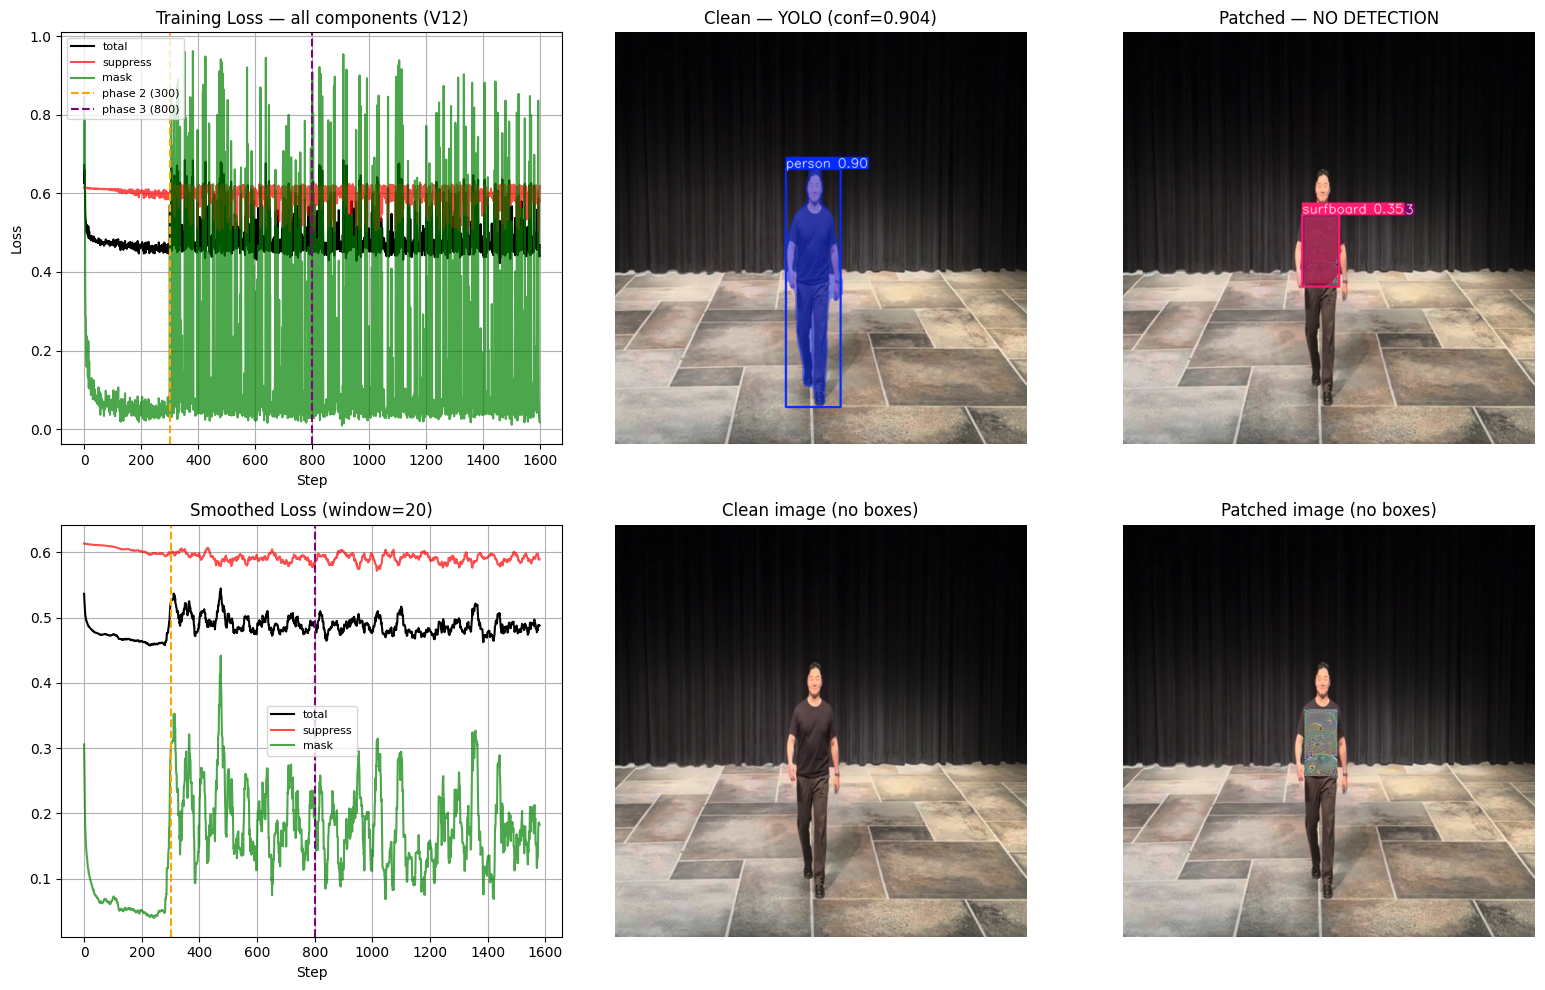

In [14]:
# Cell 13 — Visual evaluation + loss component breakdown
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: loss curves
axes[0, 0].plot(loss_history,     label='total',    color='black')
axes[0, 0].plot(suppress_history, label='suppress', color='red',   alpha=0.7)
axes[0, 0].plot(mask_history,     label='mask',     color='green', alpha=0.7)
if CURRICULUM_STEPS > 0:
    axes[0, 0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--',
                       label=f'phase 2 ({CURRICULUM_STEPS})')
axes[0, 0].axvline(x=800, color='purple', linestyle='--', label='phase 3 (800)')
axes[0, 0].set_title('Training Loss — all components (V12)')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True)

# Row 1: clean detection
axes[0, 1].imshow(cv2.cvtColor(results_clean_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Clean — YOLO (conf={yolo_clean:.3f})')
axes[0, 1].axis('off')

# Row 1: patched detection
patched_label = f'Patched — YOLO (conf={yolo_patched:.3f})' if yolo_patched else 'Patched — NO DETECTION'
axes[0, 2].imshow(cv2.cvtColor(results_patched_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[0, 2].set_title(patched_label)
axes[0, 2].axis('off')

# Row 2: smoothed loss (window=20)
window = 20
def smooth(x):
    return np.convolve(x, np.ones(window)/window, mode='valid')

axes[1, 0].plot(smooth(loss_history),     color='black', label='total')
axes[1, 0].plot(smooth(suppress_history), color='red',   label='suppress', alpha=0.7)
axes[1, 0].plot(smooth(mask_history),     color='green', label='mask',     alpha=0.7)
if CURRICULUM_STEPS > 0:
    axes[1, 0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--')
axes[1, 0].axvline(x=800, color='purple', linestyle='--')
axes[1, 0].set_title(f'Smoothed Loss (window={window})')
axes[1, 0].set_xlabel('Step')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)

# Row 2: clean image (no overlay)
axes[1, 1].imshow(cv2.cvtColor(img_eval_640, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Clean image (no boxes)')
axes[1, 1].axis('off')

# Row 2: patched image (no overlay)
axes[1, 2].imshow(cv2.cvtColor(img_patched_np, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Patched image (no boxes)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
